In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

In [2]:
import scipy.io as sio

# Load the meta.mat file
meta = sio.loadmat('data/imagenet/devkit/ILSVRC2012_devkit_t12/data/meta.mat', squeeze_me=True)['synsets']

# Filter out entries with no children (i.e., leaf nodes)
meta = [entry for entry in meta if entry[4] == 0]

# Create a mapping from class index to WNID
idx_to_wnid = {entry[0]: entry[1] for entry in meta}


import json

# Load the JSON file
with open('imagenet_class_index.json', 'r') as f:
    class_idx = json.load(f)

# Create a mapping from WNID to model class index
wnid_to_idx = {v[0]: int(k) for k, v in class_idx.items()}



# Read the ground truth labels
with open('data/imagenet/devkit/ILSVRC2012_devkit_t12/data/ILSVRC2012_validation_ground_truth.txt') as f:
    val_labels = [int(line.strip()) for line in f]

# Create the val_filenames.txt file with correct mappings
with open('data/imagenet/devkit/ILSVRC2012_devkit_t12/data/val_filenames.txt', 'w') as f:
    for i, label in enumerate(val_labels):
        fname = f"ILSVRC2012_val_{i+1:08d}.JPEG"
        wnid = idx_to_wnid[label]
        class_idx = wnid_to_idx[wnid]
        f.write(f"{fname} {class_idx}\n")



In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset

class ImageNetValDataset(Dataset):
    def __init__(self, images_dir, labels_file, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        with open(labels_file, 'r') as f:
            lines = f.readlines()
        self.samples = [line.strip().split() for line in lines]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        image_path = os.path.join(self.images_dir, filename)
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, int(label)



In [4]:
def get_imagenet_loaders(batch_size, num_workers):
    data_dir = "data/imagenet"

    # -------------------------
    # Validation loader
    # -------------------------
    images_dir = os.path.join(data_dir, "val")
    labels_file = (
        "data/imagenet/devkit/ILSVRC2012_devkit_t12/data/val_filenames.txt"
    )

    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    val_dataset = ImageNetValDataset(
        images_dir=images_dir,
        labels_file=labels_file,
        transform=val_transform,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    # -------------------------
    # Training loader
    # -------------------------
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    train_dir = os.path.join(data_dir, "train")
    train_dataset = datasets.ImageFolder(
        root=train_dir,
        transform=train_transform,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,
    )

    # -------------------------
    # Test loader
    # -------------------------
    # Standard ImageNet practice: reuse val as test
    test_loader = val_loader

    return train_loader, val_loader, test_loader


In [5]:
import torch
from torchvision import models, transforms
from torch.utils.data import DataLoader

# --------------------------------------------------
# Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Transforms (ImageNet standard)
# --------------------------------------------------
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# --------------------------------------------------
# Dataset + Loader (YOUR custom ImageNetValDataset)
# --------------------------------------------------
images_dir = "data/imagenet/val"
labels_file = "data/imagenet/devkit/ILSVRC2012_devkit_t12/data/val_filenames.txt"
batch_size = 64

dataset = ImageNetValDataset(
    images_dir=images_dir,
    labels_file=labels_file,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

ys = []
for _, y in dataloader:
    ys.append(y)
    break

y = ys[0]
print("Label min:", y.min().item())
print("Label max:", y.max().item())


# --------------------------------------------------
# Load pretrained ResNet-50
# --------------------------------------------------
model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)
model = model.to(device)
model.eval()

# --------------------------------------------------
# Evaluation
# --------------------------------------------------
correct = 0
total = 0

with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

accuracy = 100.0 * correct / total
print(f"ResNet-50 ImageNet validation accuracy: {accuracy:.2f}%")


Label min: 23
Label max: 994
ResNet-50 ImageNet validation accuracy: 76.15%


In [6]:
# =========================
# Imports
# =========================
import torch
import torch.nn as nn
import torchvision.models as tv_models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# Channel-wise gating for bottleneck width
# =========================
class ChannelGate(nn.Module):
    def __init__(self, channels, init_logit=10.0):
        super().__init__()
        # init_logit=10 => gate ~ 0.99995, almost fully open
        self.logits = nn.Parameter(torch.ones(channels) * init_logit)

    def gate_values(self):
        return torch.sigmoid(self.logits)

    def forward(self, x):
        g = self.gate_values().view(1, -1, 1, 1)
        return x * g


# =========================
# Gate utilities
# =========================
@torch.no_grad()
def gather_all_gates(model: nn.Module) -> torch.Tensor:
    gates = []
    for m in model.modules():
        if isinstance(m, ChannelGate):
            gates.append(m.gate_values().detach().flatten())

    if len(gates) == 0:
        return torch.tensor([], device=next(model.parameters()).device)

    return torch.cat(gates)


def gate_l1_sparsity_loss(model: nn.Module):
    """
    Sparsity regularization on gate values.
    Lower gate values are encouraged when this loss is minimized.
    """
    vals = []
    for m in model.modules():
        if isinstance(m, ChannelGate):
            vals.append(m.gate_values())

    if len(vals) == 0:
        return torch.tensor(0.0, device=next(model.parameters()).device)

    return torch.cat(vals).mean()


@torch.no_grad()
def harden_gates(model: nn.Module, prune_ratio: float):
    """
    Per-bottleneck hardening.

    prune_ratio = 0.1 means:
        each bottleneck keeps 90% of its internal width channels.

    This makes gates almost binary:
        kept channels   -> sigmoid(10)  ~ 1
        pruned channels -> sigmoid(-10) ~ 0
    """
    for m in model.modules():
        if isinstance(m, ChannelGate):
            g = m.gate_values()
            n = g.numel()
            k = int(round((1.0 - prune_ratio) * n))

            if k <= 0:
                m.logits.fill_(-10.0)
                continue

            if k >= n:
                m.logits.fill_(10.0)
                continue

            thresh = torch.topk(g, k, largest=True).values.min()
            keep_mask = (g >= thresh)

            m.logits.copy_(
                torch.where(
                    keep_mask,
                    torch.full_like(g, 10.0),
                    torch.full_like(g, -10.0),
                )
            )


# =========================
# Corrected Gated Bottleneck
# =========================
class WidthGatedBottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1, downsample=None):
        super().__init__()

        self.in_planes = in_planes
        self.planes = planes
        self.stride = stride

        # 1x1 reduce: in_planes -> planes
        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)

        # 3x3 spatial: planes -> planes
        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        # 1x1 expand: planes -> planes*4
        self.conv3 = nn.Conv2d(
            planes,
            planes * self.expansion,
            kernel_size=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        # IMPORTANT:
        # Gate internal bottleneck width, not final residual output.
        self.width_gate = ChannelGate(planes)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # conv1 path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Gate width after BN/ReLU
        out = self.width_gate(out)

        # conv2 path
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        # Same width gate again, so conv2 input/output and conv3 input
        # share the same surviving channel set.
        out = self.width_gate(out)

        # conv3 expands back to planes*4.
        # Do NOT gate this output, otherwise residual addition becomes problematic.
        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)

        return out


# =========================
# Corrected Gated ResNet-50
# =========================
class WidthGatedResNet50(nn.Module):
    def __init__(self, num_classes=1000, init_weights=False):
        super().__init__()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.layer1 = self._make_layer(64, blocks=3, stride=1)
        self.layer2 = self._make_layer(128, blocks=4, stride=2)
        self.layer3 = self._make_layer(256, blocks=6, stride=2)
        self.layer4 = self._make_layer(512, blocks=3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(
            512 * WidthGatedBottleneck.expansion,
            num_classes
        )

        if init_weights:
            self._init_weights()

    def _make_layer(self, planes, blocks, stride):
        downsample = None
        out_channels = planes * WidthGatedBottleneck.expansion

        if stride != 1 or self.in_planes != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_planes,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        layers = []

        layers.append(
            WidthGatedBottleneck(
                in_planes=self.in_planes,
                planes=planes,
                stride=stride,
                downsample=downsample
            )
        )

        self.in_planes = out_channels

        for _ in range(1, blocks):
            layers.append(
                WidthGatedBottleneck(
                    in_planes=self.in_planes,
                    planes=planes,
                    stride=1,
                    downsample=None
                )
            )

        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        return self.fc(x)


# =========================
# Load torchvision pretrained ResNet-50 weights
# =========================
def load_torchvision_pretrained_into_width_gated(model: WidthGatedResNet50):
    """
    Copies torchvision ResNet-50 weights into the width-gated model.
    Gate parameters remain initialized as almost fully open.
    """

    try:
        from torchvision.models import resnet50, ResNet50_Weights

        # Use the same pretrained version as your dense baseline.
        base = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

    except Exception:
        base = tv_models.resnet50(pretrained=True)

    base_sd = base.state_dict()
    gated_sd = model.state_dict()

    copied = 0
    skipped = []

    for k in gated_sd.keys():
        # skip gates
        if "width_gate" in k:
            skipped.append(k)
            continue

        if k in base_sd and gated_sd[k].shape == base_sd[k].shape:
            gated_sd[k] = base_sd[k]
            copied += 1
        else:
            skipped.append(k)

    model.load_state_dict(gated_sd, strict=False)

    print(f"Loaded pretrained weights into width-gated ResNet-50.")
    print(f"Copied tensors: {copied}")
    print(f"Skipped tensors: {len(skipped)}")

    return model


# =========================
# Build corrected model
# =========================
model = WidthGatedResNet50(num_classes=1000, init_weights=False)
model = load_torchvision_pretrained_into_width_gated(model)
model = model.to(DEVICE)
model.eval()

x = torch.randn(2, 3, 224, 224).to(DEVICE)

with torch.no_grad():
    y = model(x)

print(y.shape)  # expected: torch.Size([2, 1000])
print("Total gate values:", gather_all_gates(model).numel())
print("Mean initial gate value:", gather_all_gates(model).mean().item())

Loaded pretrained weights into width-gated ResNet-50.
Copied tensors: 320
Skipped tensors: 16
torch.Size([2, 1000])
Total gate values: 3776
Mean initial gate value: 0.9999546408653259


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class SoftBinnedECELoss(nn.Module):
    """
    Soft-binned Expected Calibration Error (SB-ECE, L2 form)

    - Soft binning via Gaussian-like membership over confidence values
    - Bin anchors at:
        (1/(2m), 3/(2m), ..., (2m-1)/(2m))
    - Returns:
        sqrt( sum_b w_b * (conf_b - acc_b)^2 )

    Args:
        bins (int): number of confidence bins
        temperature (float): softness of bin membership
                             smaller => sharper assignment
        eps (float): numerical stability
    """
    def __init__(self, bins=15, temperature=0.05, eps=1e-8):
        super().__init__()
        self.bins = bins
        self.temperature = temperature
        self.eps = eps

        anchors = np.arange(1.0 / (2 * bins), 1.0, 1.0 / bins, dtype=np.float32)
        self.register_buffer("anchors", torch.tensor(anchors, dtype=torch.float32))

    def forward(self, logits, labels):
        """
        logits: [N, C]
        labels: [N]
        """
        probs = F.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)             # [N]
        acc = pred.eq(labels).float()             # [N]

        # [N, 1], [1, m]
        conf_tile = conf.unsqueeze(1)
        anchors = self.anchors.unsqueeze(0)

        # Soft membership (Gaussian-like kernel over anchors)
        # Shape: [N, m]
        scores = -((conf_tile - anchors) ** 2) / max(self.temperature, self.eps)
        c = F.softmax(scores, dim=1)

        # Per-bin soft counts
        sum_c = c.sum(dim=0)                                  # [m]
        sum_c_safe = torch.clamp(sum_c, min=self.eps)

        # Soft bin confidence / accuracy
        conf_b = (c * conf_tile).sum(dim=0) / sum_c_safe      # [m]
        acc_b  = (c * acc.unsqueeze(1)).sum(dim=0) / sum_c_safe  # [m]

        # Bin weights
        w = sum_c / torch.clamp(sum_c.sum(), min=self.eps)

        # L2 SB-ECE
        sb_ece = torch.sqrt(torch.sum(w * (conf_b - acc_b) ** 2) + self.eps)

        return sb_ece

In [8]:
@torch.no_grad()
def collect_logits_and_labels(model, loader, device):
    model.eval()
    logits_list, labels_list = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)

        logits_list.append(logits.detach().cpu())
        labels_list.append(y.detach().cpu())

    return torch.cat(logits_list, 0), torch.cat(labels_list, 0)


@torch.no_grad()
def acc_from_logits(logits, labels):
    return float((logits.argmax(1) == labels).float().mean().item())


@torch.no_grad()
def nll_from_logits(logits, labels):
    return float(F.cross_entropy(logits, labels, reduction="mean").item())


@torch.no_grad()
def ece_from_logits(logits, labels, n_bins=15, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    conf, pred = probs.max(1)
    acc = pred.eq(labels).float()

    edges = torch.linspace(0, 1, n_bins + 1, device=logits.device)
    ece = torch.zeros(1, device=logits.device)

    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]

        if b == n_bins - 1:
            inb = (conf >= lo) & (conf <= hi)
        else:
            inb = (conf >= lo) & (conf < hi)

        p = inb.float().mean()

        if p.item() > 0:
            ece += p * torch.abs(conf[inb].mean() - acc[inb].mean())

    return float(ece.item())


@torch.no_grad()
def ks_calibration_error(logits, labels, temperature=1.0):
    probs = F.softmax(logits / temperature, dim=1)
    conf, pred = probs.max(1)
    correct = pred.eq(labels).float()

    conf_sorted, idx = torch.sort(conf)
    corr_sorted = correct[idx]

    denom = torch.arange(
        1,
        len(conf_sorted) + 1,
        device=logits.device
    ).float()

    cum_acc = torch.cumsum(corr_sorted, 0) / denom
    cum_conf = torch.cumsum(conf_sorted, 0) / denom

    return float(torch.max(torch.abs(cum_acc - cum_conf)).item())


@torch.no_grad()
def mean_sweep_ce(logits, labels, bin_list, temperature=1.0):
    vals = [
        ece_from_logits(
            logits,
            labels,
            n_bins=b,
            temperature=temperature
        )
        for b in bin_list
    ]

    return float(np.mean(vals))


def fit_temperature(logits_val_cpu, labels_val_cpu, device, max_iter=50):
    logits = logits_val_cpu.to(device)
    labels = labels_val_cpu.to(device)

    logT = torch.zeros(1, device=device, requires_grad=True)

    opt = torch.optim.LBFGS(
        [logT],
        lr=0.5,
        max_iter=max_iter,
        line_search_fn="strong_wolfe"
    )

    def closure():
        opt.zero_grad()

        T = torch.exp(logT)
        loss = F.cross_entropy(logits / T, labels)

        loss.backward()
        return loss

    opt.step(closure)

    T = float(torch.exp(logT).detach().cpu().item())

    return max(1e-3, min(T, 100.0))


def evaluate_all_metrics(model, val_loader, test_loader, device):
    """
    Important:
    Do NOT put @torch.no_grad() on this function,
    because fit_temperature() needs gradients.
    """

    # Collect logits without gradients
    logits_val, labels_val = collect_logits_and_labels(
        model,
        val_loader,
        device
    )

    logits_test, labels_test = collect_logits_and_labels(
        model,
        test_loader,
        device
    )

    logits_test = logits_test.to(device)
    labels_test = labels_test.to(device)

    # Base metrics
    acc = acc_from_logits(logits_test, labels_test)
    nll = nll_from_logits(logits_test, labels_test)
    ece = ece_from_logits(
        logits_test,
        labels_test,
        n_bins=ECE_BINS
    )
    ks = ks_calibration_error(logits_test, labels_test)
    ms = mean_sweep_ce(
        logits_test,
        labels_test,
        MEAN_SWEEP_BINS
    )

    # Temperature scaling
    T = fit_temperature(
        logits_val,
        labels_val,
        device=device
    )

    ts_nll = nll_from_logits(logits_test / T, labels_test)

    ts_ece = ece_from_logits(
        logits_test,
        labels_test,
        n_bins=ECE_BINS,
        temperature=T
    )

    ts_ks = ks_calibration_error(
        logits_test,
        labels_test,
        temperature=T
    )

    ts_ms = mean_sweep_ce(
        logits_test,
        labels_test,
        MEAN_SWEEP_BINS,
        temperature=T
    )

    return {
        "acc": acc,
        "nll": nll,
        "ece": ece,
        "ts_ece": ts_ece,
        "ks": ks,
        "ts_ks": ts_ks,
        "mean_sweep_ce": ms,
        "ts_mean_sweep_ce": ts_ms,
        "ts_temperature": T,
        "ts_nll": ts_nll,
    }

In [9]:
# ============================================================
# FULL WIDTH-GATED ADAPTATION BLOCK
# Run this as one cell
# ============================================================

import os
import copy
import time
import torch
import torch.nn as nn
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Helper: beta warmup
# ============================================================
def get_beta_sbece(epoch, beta_target=1.0, warmup_epochs=5):
    if warmup_epochs <= 0:
        return beta_target

    if epoch >= warmup_epochs:
        return beta_target

    return beta_target * float(epoch + 1) / warmup_epochs


# ============================================================
# Helper: parameter counting
# ============================================================
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ============================================================
# Helper: freeze backbone, train only gates
# ============================================================
def freeze_backbone_train_only_gates(model):
    for name, p in model.named_parameters():
        p.requires_grad = False

    for name, p in model.named_parameters():
        if "width_gate.logits" in name:
            p.requires_grad = True

    return model


# ============================================================
# Helper: keep BN frozen during gate-only adaptation
# ============================================================
def set_bn_eval(model):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()


# ============================================================
# One training epoch: NLL + SB-ECE + gate sparsity
# ============================================================
def train_one_epoch_nll_sbece(
    model,
    loader,
    optimizer,
    device,
    nll_loss_fn,
    sbece_loss_fn,
    beta_sbece=1.0,
    lambda_sparse=1e-3,
    sbece_every=1,
    grad_clip=None,
    freeze_bn=True,
):
    model.train()

    if freeze_bn:
        set_bn_eval(model)

    total_samples = 0
    sum_total = 0.0
    sum_nll = 0.0
    sum_sbece = 0.0
    sum_sparse = 0.0
    correct = 0

    for step, (x, y) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)

        # NLL / CE
        nll = nll_loss_fn(logits, y)

        # SB-ECE
        if sbece_every > 0 and (step % sbece_every) == 0:
            sbece = sbece_loss_fn(logits, y)
        else:
            sbece = logits.new_zeros(())

        # Gate sparsity
        if lambda_sparse > 0:
            sparse = gate_l1_sparsity_loss(model)
        else:
            sparse = logits.new_zeros(())

        loss = nll + beta_sbece * sbece + lambda_sparse * sparse

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                grad_clip
            )

        optimizer.step()

        bs = y.size(0)
        total_samples += bs

        sum_total += float(loss.item()) * bs
        sum_nll += float(nll.item()) * bs
        sum_sbece += float(sbece.item()) * bs
        sum_sparse += float(sparse.item()) * bs

        pred = logits.argmax(dim=1)
        correct += pred.eq(y).sum().item()

    denom = max(total_samples, 1)

    return {
        "loss": sum_total / denom,
        "nll": sum_nll / denom,
        "sbece": sum_sbece / denom,
        "sparse": sum_sparse / denom,
        "acc1": 100.0 * correct / denom,
    }


# ============================================================
# Evaluation epoch
# ============================================================
@torch.no_grad()
def evaluate_one_epoch(
    model,
    loader,
    device,
    nll_loss_fn,
    sbece_loss_fn=None,
):
    model.eval()

    total_samples = 0
    sum_nll = 0.0
    sum_sbece = 0.0
    correct = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)

        nll = nll_loss_fn(logits, y)

        if sbece_loss_fn is not None:
            sbece = sbece_loss_fn(logits, y)
        else:
            sbece = logits.new_zeros(())

        bs = y.size(0)
        total_samples += bs

        sum_nll += float(nll.item()) * bs
        sum_sbece += float(sbece.item()) * bs

        pred = logits.argmax(dim=1)
        correct += pred.eq(y).sum().item()

    denom = max(total_samples, 1)

    return {
        "nll": sum_nll / denom,
        "sbece": sum_sbece / denom,
        "acc1": 100.0 * correct / denom,
    }


# ============================================================
# Main width-gated adaptation function
# ============================================================
def run_width_gated_adaptation_for_pruning(
    train_loader,
    val_loader,
    save_dir="PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT",
    num_classes=1000,
    epochs=10,
    gate_lr=1e-3,
    beta_sbece=1.0,
    lambda_sparse=1e-3,
    sbece_bins=15,
    sbece_temp=0.05,
    sbece_every=1,
    warmup_beta_epochs=2,
    grad_clip=5.0,
    train_only_gates=True,
):
    os.makedirs(save_dir, exist_ok=True)

    # -------------------------
    # Build corrected width-gated model
    # -------------------------
    model = WidthGatedResNet50(num_classes=num_classes, init_weights=False)
    model = load_torchvision_pretrained_into_width_gated(model)
    model = model.to(DEVICE)

    # -------------------------
    # Freeze backbone if gate-only adaptation
    # -------------------------
    if train_only_gates:
        model = freeze_backbone_train_only_gates(model)

    print("=" * 80)
    print("Starting WIDTH-GATED adaptation for ImageNet ResNet-50")
    print(f"Train only gates : {train_only_gates}")
    print(f"Trainable params : {count_trainable_params(model)}")
    print(f"Epochs           : {epochs}")
    print(f"gate_lr          : {gate_lr}")
    print(f"beta_sbece       : {beta_sbece}")
    print(f"lambda_sparse    : {lambda_sparse}")
    print(f"sbece_every      : {sbece_every}")
    print("=" * 80)

    # -------------------------
    # Losses
    # -------------------------
    nll_loss_fn = nn.CrossEntropyLoss()

    sbece_loss_fn = SoftBinnedECELoss(
        bins=sbece_bins,
        temperature=sbece_temp
    ).to(DEVICE)

    # -------------------------
    # Optimizer
    # -------------------------
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=gate_lr,
        weight_decay=0.0
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = []
    best_score = float("inf")
    best_state = None

    # -------------------------
    # Epoch loop
    # -------------------------
    for epoch in range(epochs):
        t0 = time.time()

        beta_eff = get_beta_sbece(
            epoch=epoch,
            beta_target=beta_sbece,
            warmup_epochs=warmup_beta_epochs
        )

        train_stats = train_one_epoch_nll_sbece(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=DEVICE,
            nll_loss_fn=nll_loss_fn,
            sbece_loss_fn=sbece_loss_fn,
            beta_sbece=beta_eff,
            lambda_sparse=lambda_sparse,
            sbece_every=sbece_every,
            grad_clip=grad_clip,
            freeze_bn=train_only_gates,
        )

        val_stats = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            device=DEVICE,
            nll_loss_fn=nll_loss_fn,
            sbece_loss_fn=sbece_loss_fn,
        )

        scheduler.step()

        gates = gather_all_gates(model)

        if gates.numel() > 0:
            gate_mean = float(gates.mean().item())
            gate_min = float(gates.min().item())
            gate_max = float(gates.max().item())
            gate_std = float(gates.std().item())
        else:
            gate_mean = 1.0
            gate_min = 1.0
            gate_max = 1.0
            gate_std = 0.0

        epoch_time = time.time() - t0
        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch + 1,
            "lr": current_lr,
            "beta_sbece_eff": beta_eff,

            "train_loss": train_stats["loss"],
            "train_nll": train_stats["nll"],
            "train_sbece": train_stats["sbece"],
            "train_sparse": train_stats["sparse"],
            "train_acc1": train_stats["acc1"],

            "val_nll": val_stats["nll"],
            "val_sbece": val_stats["sbece"],
            "val_acc1": val_stats["acc1"],

            "gate_mean": gate_mean,
            "gate_min": gate_min,
            "gate_max": gate_max,
            "gate_std": gate_std,

            "epoch_time_sec": epoch_time,
        }

        history.append(row)

        # Selection criterion: calibration-aware recovery score
        current_score = val_stats["nll"] + beta_sbece * val_stats["sbece"]

        if current_score < best_score:
            best_score = current_score
            best_state = copy.deepcopy(model.state_dict())

            torch.save(
                {
                    "epoch": epoch + 1,
                    "state_dict": model.state_dict(),
                    "best_score": best_score,
                    "val_acc1": val_stats["acc1"],
                    "val_nll": val_stats["nll"],
                    "val_sbece": val_stats["sbece"],
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                },
                os.path.join(save_dir, "best_width_gated_model.pth")
            )

        torch.save(
            {
                "epoch": epoch + 1,
                "state_dict": model.state_dict(),
                "best_score": best_score,
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
            },
            os.path.join(save_dir, "latest_width_gated_model.pth")
        )

        df_hist = pd.DataFrame(history)
        df_hist.to_csv(
            os.path.join(save_dir, "training_log.csv"),
            index=False
        )

        print(
            f"[Epoch {epoch+1:03d}/{epochs}] "
            f"lr={current_lr:.6f} | "
            f"beta={beta_eff:.3f} | "
            f"train_acc={train_stats['acc1']:.2f} | "
            f"val_acc={val_stats['acc1']:.2f} | "
            f"train_nll={train_stats['nll']:.4f} | "
            f"val_nll={val_stats['nll']:.4f} | "
            f"train_sbece={train_stats['sbece']:.4f} | "
            f"val_sbece={val_stats['sbece']:.4f} | "
            f"gate_mean={gate_mean:.5f} | "
            f"gate_min={gate_min:.5f} | "
            f"gate_max={gate_max:.5f} | "
            f"gate_std={gate_std:.5f} | "
            f"time={epoch_time/60:.1f}m"
        )

    # -------------------------
    # Save final
    # -------------------------
    torch.save(
        {
            "epoch": epochs,
            "state_dict": model.state_dict(),
            "best_score": best_score,
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
        },
        os.path.join(save_dir, "final_width_gated_model.pth")
    )

    # Restore best state
    if best_state is not None:
        model.load_state_dict(best_state)

    df_hist = pd.DataFrame(history)
    df_hist.to_csv(
        os.path.join(save_dir, "training_log.csv"),
        index=False
    )

    print("=" * 80)
    print(f"Gate adaptation finished. Best score = {best_score:.4f}")
    print(f"Saved in: {save_dir}")
    print("=" * 80)

    return model, df_hist

In [10]:
from torchvision import datasets, transforms

# ----------- DataLoader -----------
data_dir = "data/imagenet"
batch_size = 16
num_workers = 8
images_dir = 'data/imagenet/val'
labels_file = 'data/imagenet/devkit/ILSVRC2012_devkit_t12/data/val_filenames.txt'
val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
])
val_dataset = ImageNetValDataset(images_dir, labels_file, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
train_dir = os.path.join(data_dir, "train")
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    
test_loader = val_loader

In [22]:
model, df_hist = run_width_gated_adaptation_for_pruning(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    gate_lr=1e-3,
    beta_sbece=1.0,
    lambda_sparse=1e-3,
    sbece_every=1,
    train_only_gates=True,
)

Loaded pretrained weights into width-gated ResNet-50.
Copied tensors: 320
Skipped tensors: 16
Starting WIDTH-GATED adaptation for ImageNet ResNet-50
Train only gates : True
Trainable params : 3776
Epochs           : 10
gate_lr          : 0.001
beta_sbece       : 1.0
lambda_sparse    : 0.001
sbece_every      : 1
[Epoch 001/10] lr=0.000976 | beta=0.500 | train_acc=77.94 | val_acc=76.17 | train_nll=0.8954 | val_nll=0.9685 | train_sbece=0.1199 | val_sbece=0.1297 | gate_mean=0.99895 | gate_min=0.66004 | gate_max=1.00000 | gate_std=0.00959 | time=62.0m
[Epoch 002/10] lr=0.000905 | beta=1.000 | train_acc=78.06 | val_acc=76.18 | train_nll=0.8895 | val_nll=0.9672 | train_sbece=0.1189 | val_sbece=0.1300 | gate_mean=0.99715 | gate_min=0.73764 | gate_max=1.00000 | gate_std=0.01593 | time=61.9m
[Epoch 003/10] lr=0.000794 | beta=1.000 | train_acc=78.16 | val_acc=76.22 | train_nll=0.8865 | val_nll=0.9662 | train_sbece=0.1187 | val_sbece=0.1295 | gate_mean=0.99552 | gate_min=0.69403 | gate_max=1.00000

In [15]:
# ============================================================
# STRUCTURAL PRUNING BLOCK
# Build physically slim ResNet-50 from WidthGatedResNet50
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as tv_models
import copy

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Slim bottleneck: no gates, physically smaller internal width
# ============================================================
class SlimBottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, width, stride=1, downsample=None):
        super().__init__()

        self.in_planes = in_planes
        self.planes = planes
        self.width = width
        self.stride = stride

        # Physically reduced bottleneck width
        self.conv1 = nn.Conv2d(
            in_planes,
            width,
            kernel_size=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(width)

        self.conv2 = nn.Conv2d(
            width,
            width,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(width)

        # Expand back to original residual dimension
        self.conv3 = nn.Conv2d(
            width,
            planes * self.expansion,
            kernel_size=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)

        return out


# ============================================================
# Slim ResNet-50
# ============================================================
class SlimResNet50(nn.Module):
    def __init__(self, widths_by_layer, num_classes=1000):
        super().__init__()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1
        )

        self.layer1 = self._make_layer(
            planes=64,
            widths=widths_by_layer["layer1"],
            stride=1
        )
        self.layer2 = self._make_layer(
            planes=128,
            widths=widths_by_layer["layer2"],
            stride=2
        )
        self.layer3 = self._make_layer(
            planes=256,
            widths=widths_by_layer["layer3"],
            stride=2
        )
        self.layer4 = self._make_layer(
            planes=512,
            widths=widths_by_layer["layer4"],
            stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * SlimBottleneck.expansion, num_classes)

    def _make_layer(self, planes, widths, stride):
        downsample = None
        out_channels = planes * SlimBottleneck.expansion

        if stride != 1 or self.in_planes != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_planes,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        layers = []

        layers.append(
            SlimBottleneck(
                in_planes=self.in_planes,
                planes=planes,
                width=widths[0],
                stride=stride,
                downsample=downsample
            )
        )

        self.in_planes = out_channels

        for i in range(1, len(widths)):
            layers.append(
                SlimBottleneck(
                    in_planes=self.in_planes,
                    planes=planes,
                    width=widths[i],
                    stride=1,
                    downsample=None
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        return self.fc(x)


# ============================================================
# BN copy helpers
# ============================================================
@torch.no_grad()
def copy_bn_full(src_bn, dst_bn):
    dst_bn.weight.copy_(src_bn.weight)
    dst_bn.bias.copy_(src_bn.bias)
    dst_bn.running_mean.copy_(src_bn.running_mean)
    dst_bn.running_var.copy_(src_bn.running_var)

    if hasattr(src_bn, "num_batches_tracked") and hasattr(dst_bn, "num_batches_tracked"):
        dst_bn.num_batches_tracked.copy_(src_bn.num_batches_tracked)


@torch.no_grad()
def copy_bn_subset(src_bn, dst_bn, idx):
    idx = idx.to(src_bn.weight.device)

    dst_bn.weight.copy_(src_bn.weight.index_select(0, idx))
    dst_bn.bias.copy_(src_bn.bias.index_select(0, idx))
    dst_bn.running_mean.copy_(src_bn.running_mean.index_select(0, idx))
    dst_bn.running_var.copy_(src_bn.running_var.index_select(0, idx))

    if hasattr(src_bn, "num_batches_tracked") and hasattr(dst_bn, "num_batches_tracked"):
        dst_bn.num_batches_tracked.copy_(src_bn.num_batches_tracked)


# ============================================================
# Get keep indices from learned width gates
# ============================================================
@torch.no_grad()
def get_keep_indices_from_width_gates(gated_model, prune_ratio):
    """
    prune_ratio = 0.10 means remove 10% internal width channels
    inside every bottleneck block.

    IMPORTANT:
    This does NOT modify the gated model.
    So you can reuse the same adapted model for multiple pruning ratios.
    """

    keep_indices = {}
    widths_by_layer = {}

    for layer_name in ["layer1", "layer2", "layer3", "layer4"]:
        layer = getattr(gated_model, layer_name)
        widths_by_layer[layer_name] = []

        for block_idx, block in enumerate(layer):
            g = block.width_gate.gate_values().detach()

            n = g.numel()
            k = int(round((1.0 - prune_ratio) * n))
            k = max(1, min(k, n))

            idx = torch.topk(g, k, largest=True).indices
            idx = torch.sort(idx).values.long()

            keep_indices[(layer_name, block_idx)] = idx.cpu()
            widths_by_layer[layer_name].append(k)

    return keep_indices, widths_by_layer


# ============================================================
# Copy sliced weights from width-gated model to slim model
# ============================================================
@torch.no_grad()
def copy_sliced_weights_to_slim(gated_model, slim_model, keep_indices):
    gated_model.eval()
    slim_model.eval()

    # Stem
    slim_model.conv1.weight.copy_(gated_model.conv1.weight)
    copy_bn_full(gated_model.bn1, slim_model.bn1)

    # Layers
    for layer_name in ["layer1", "layer2", "layer3", "layer4"]:
        gated_layer = getattr(gated_model, layer_name)
        slim_layer = getattr(slim_model, layer_name)

        for block_idx, (gb, sb) in enumerate(zip(gated_layer, slim_layer)):
            idx = keep_indices[(layer_name, block_idx)].to(gb.conv1.weight.device)

            # conv1: keep selected output channels
            sb.conv1.weight.copy_(
                gb.conv1.weight.index_select(0, idx)
            )
            copy_bn_subset(gb.bn1, sb.bn1, idx)

            # conv2: keep selected input and output channels
            w2 = gb.conv2.weight.index_select(0, idx).index_select(1, idx)
            sb.conv2.weight.copy_(w2)
            copy_bn_subset(gb.bn2, sb.bn2, idx)

            # conv3: keep selected input channels, output unchanged
            w3 = gb.conv3.weight.index_select(1, idx)
            sb.conv3.weight.copy_(w3)
            copy_bn_full(gb.bn3, sb.bn3)

            # Downsample is unchanged
            if gb.downsample is not None:
                sb.downsample[0].weight.copy_(gb.downsample[0].weight)
                copy_bn_full(gb.downsample[1], sb.downsample[1])

    # FC unchanged
    slim_model.fc.weight.copy_(gated_model.fc.weight)
    slim_model.fc.bias.copy_(gated_model.fc.bias)

    return slim_model


# ============================================================
# Build physically pruned ResNet-50
# ============================================================
def build_slim_resnet50_from_width_gated(gated_model, prune_ratio, num_classes=1000):
    """
    Creates a physically smaller ResNet-50 by slicing bottleneck width channels.
    This is the real FLOP-reducing structured pruning step.
    """

    keep_indices, widths_by_layer = get_keep_indices_from_width_gates(
        gated_model,
        prune_ratio=prune_ratio
    )

    slim_model = SlimResNet50(
        widths_by_layer=widths_by_layer,
        num_classes=num_classes
    )

    slim_model = slim_model.to(next(gated_model.parameters()).device)

    slim_model = copy_sliced_weights_to_slim(
        gated_model=gated_model,
        slim_model=slim_model,
        keep_indices=keep_indices
    )

    return slim_model, widths_by_layer, keep_indices


# ============================================================
# FLOP counter
# ============================================================
def count_model_params(model):
    return sum(p.numel() for p in model.parameters())


def count_fvcore_gflops(model, device=DEVICE, input_size=(1, 3, 224, 224)):
    try:
        from fvcore.nn import FlopCountAnalysis

        model.eval()
        x = torch.randn(*input_size).to(device)

        with torch.no_grad():
            flops = FlopCountAnalysis(model, x)

        return flops.total() / 1e9

    except Exception as e:
        print("fvcore FLOP counting failed:", e)
        return None

In [21]:
# ============================================================
# Build physically pruned slim models for multiple ratios
# + BN recalibration without reset
# + evaluation
# + save per-ratio checkpoint and global CSV
# ============================================================

import os
import torch
import torch.nn as nn
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Pruning ratios to build
# ------------------------------------------------------------

PRUNE_RATIOS = [0.10, 0.30, 0.50, 0.70, 0.90]

SAVE_DIR = (
    "PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/"
    "WIDTH_GATE_ADAPT"
)

os.makedirs(SAVE_DIR, exist_ok=True)

# If True, already saved PRUNE_X checkpoints will be skipped
SKIP_IF_EXISTS = True


# ------------------------------------------------------------
# Check available model variables
# ------------------------------------------------------------

print("Available nn.Module variables:")
for name, obj in list(globals().items()):
    if isinstance(obj, nn.Module):
        print(name, "->", obj.__class__.__name__)

# IMPORTANT:
# This should be your trained width-gated model after 10-epoch gate adaptation.
adapted_gated_model = model

adapted_gated_model = adapted_gated_model.to(DEVICE)
adapted_gated_model.eval()


# ------------------------------------------------------------
# Losses for evaluation
# ------------------------------------------------------------

nll_loss_fn = nn.CrossEntropyLoss()

sbece_loss_fn = SoftBinnedECELoss(
    bins=15,
    temperature=0.05
).to(DEVICE)


# ------------------------------------------------------------
# BN recalibration WITHOUT reset
# ------------------------------------------------------------

@torch.no_grad()
def recalibrate_bn_no_reset(model, loader, device, num_batches=500):
    """
    Recompute BN running stats without resetting running_mean/running_var.
    Safer for ImageNet than full BN reset.
    """
    bn_layers = []

    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            if m.track_running_stats:
                bn_layers.append(m)

    print(f"BN layers recalibrating: {len(bn_layers)}")

    model.eval()

    old_momentums = {}

    for bn in bn_layers:
        old_momentums[bn] = bn.momentum
        bn.train()

    used_batches = 0

    for batch_idx, (x, _) in enumerate(loader):
        if batch_idx >= num_batches:
            break

        x = x.to(device, non_blocking=True)
        _ = model(x)

        used_batches += 1

    for bn in bn_layers:
        bn.momentum = old_momentums[bn]

    model.eval()

    print(f"BN stats updated using {used_batches} batches.")
    return model


# ------------------------------------------------------------
# Evaluate adapted width-gated model once
# ------------------------------------------------------------

adapted_metrics = evaluate_one_epoch(
    model=adapted_gated_model,
    loader=val_loader,
    device=DEVICE,
    nll_loss_fn=nll_loss_fn,
    sbece_loss_fn=sbece_loss_fn,
)

print("=" * 80)
print("Adapted width-gated model:")
print(adapted_metrics)
print("=" * 80)


# ------------------------------------------------------------
# Main loop over pruning ratios
# ------------------------------------------------------------

summary_rows = []

for PRUNE_RATIO in PRUNE_RATIOS:
    PRUNE_PERCENT = int(round(PRUNE_RATIO * 100))

    print("\n" + "=" * 100)
    print(f"Processing physical slim ResNet-50 | PRUNE_{PRUNE_PERCENT}")
    print("=" * 100)

    PRUNE_SAVE_DIR = os.path.join(
        SAVE_DIR,
        f"PRUNE_{PRUNE_PERCENT}"
    )

    os.makedirs(PRUNE_SAVE_DIR, exist_ok=True)

    post_bn_ckpt_path = os.path.join(
        PRUNE_SAVE_DIR,
        f"resnet50_imagenet_prune{PRUNE_PERCENT}_slim_post_bn_no_reset.pth"
    )

    ratio_csv_path = os.path.join(
        PRUNE_SAVE_DIR,
        "post_bn_metrics_summary.csv"
    )

    # ------------------------------------------------------------
    # If checkpoint already exists, load existing summary and skip
    # ------------------------------------------------------------

    if SKIP_IF_EXISTS and os.path.exists(post_bn_ckpt_path):
        print(f"Checkpoint already exists for PRUNE_{PRUNE_PERCENT}. Skipping rebuild.")
        print(post_bn_ckpt_path)

        if os.path.exists(ratio_csv_path):
            df_existing = pd.read_csv(ratio_csv_path)
            summary_rows.extend(df_existing.to_dict("records"))
            print(f"Loaded existing summary from: {ratio_csv_path}")
        else:
            ckpt_existing = torch.load(post_bn_ckpt_path, map_location="cpu")

            pre_bn_metrics = ckpt_existing.get("pre_bn_metrics", {})
            post_bn_metrics = ckpt_existing.get("post_bn_metrics", {})
            adapted_metrics_ckpt = ckpt_existing.get("adapted_metrics", adapted_metrics)

            ratio_summary = {
                "prune_ratio": PRUNE_RATIO,
                "prune_percent": PRUNE_PERCENT,

                "adapted_acc1": adapted_metrics_ckpt.get("acc1", None),
                "adapted_nll": adapted_metrics_ckpt.get("nll", None),
                "adapted_sbece": adapted_metrics_ckpt.get("sbece", None),

                "pre_bn_acc1": pre_bn_metrics.get("acc1", None),
                "pre_bn_nll": pre_bn_metrics.get("nll", None),
                "pre_bn_sbece": pre_bn_metrics.get("sbece", None),

                "post_bn_acc1": post_bn_metrics.get("acc1", None),
                "post_bn_nll": post_bn_metrics.get("nll", None),
                "post_bn_sbece": post_bn_metrics.get("sbece", None),

                "checkpoint": post_bn_ckpt_path,
            }

            pd.DataFrame([ratio_summary]).to_csv(ratio_csv_path, index=False)
            summary_rows.append(ratio_summary)

        continue

    # ------------------------------------------------------------
    # Build physical slim model
    # ------------------------------------------------------------

    slim_model, widths_by_layer, keep_indices = build_slim_resnet50_from_width_gated(
        gated_model=adapted_gated_model,
        prune_ratio=PRUNE_RATIO,
        num_classes=1000,
    )

    slim_model = slim_model.to(DEVICE)
    slim_model.eval()

    print("Built physical slim model.")
    print("Widths by layer:")
    print(widths_by_layer)

    # ------------------------------------------------------------
    # Evaluate before BN recalibration
    # ------------------------------------------------------------

    pre_bn_metrics = evaluate_one_epoch(
        model=slim_model,
        loader=val_loader,
        device=DEVICE,
        nll_loss_fn=nll_loss_fn,
        sbece_loss_fn=sbece_loss_fn,
    )

    print(f"PRUNE_{PRUNE_PERCENT} slim model BEFORE BN recalibration:")
    print(pre_bn_metrics)

    # ------------------------------------------------------------
    # BN recalibration WITHOUT reset
    # ------------------------------------------------------------

    slim_model = recalibrate_bn_no_reset(
        model=slim_model,
        loader=train_loader,
        device=DEVICE,
        num_batches=500,
    )

    # ------------------------------------------------------------
    # Evaluate after BN recalibration
    # ------------------------------------------------------------

    post_bn_metrics = evaluate_one_epoch(
        model=slim_model,
        loader=val_loader,
        device=DEVICE,
        nll_loss_fn=nll_loss_fn,
        sbece_loss_fn=sbece_loss_fn,
    )

    print(f"PRUNE_{PRUNE_PERCENT} slim model AFTER BN recalibration, no reset:")
    print(post_bn_metrics)

    # ------------------------------------------------------------
    # Save post-BN slim model
    # ------------------------------------------------------------

    torch.save(
        {
            "state_dict": slim_model.state_dict(),
            "prune_ratio": PRUNE_RATIO,
            "prune_percent": PRUNE_PERCENT,
            "widths_by_layer": widths_by_layer,
            "keep_indices": keep_indices,
            "adapted_metrics": adapted_metrics,
            "pre_bn_metrics": pre_bn_metrics,
            "post_bn_metrics": post_bn_metrics,
            "note": "Physical slim ResNet-50 after BN recalibration without BN reset.",
        },
        post_bn_ckpt_path,
    )

    print("Saved post-BN slim model to:")
    print(post_bn_ckpt_path)

    # ------------------------------------------------------------
    # Save per-ratio metrics CSV
    # ------------------------------------------------------------

    ratio_summary = {
        "prune_ratio": PRUNE_RATIO,
        "prune_percent": PRUNE_PERCENT,

        "adapted_acc1": adapted_metrics["acc1"],
        "adapted_nll": adapted_metrics["nll"],
        "adapted_sbece": adapted_metrics["sbece"],

        "pre_bn_acc1": pre_bn_metrics["acc1"],
        "pre_bn_nll": pre_bn_metrics["nll"],
        "pre_bn_sbece": pre_bn_metrics["sbece"],

        "post_bn_acc1": post_bn_metrics["acc1"],
        "post_bn_nll": post_bn_metrics["nll"],
        "post_bn_sbece": post_bn_metrics["sbece"],

        "checkpoint": post_bn_ckpt_path,
    }

    pd.DataFrame([ratio_summary]).to_csv(
        ratio_csv_path,
        index=False
    )

    summary_rows.append(ratio_summary)

    # Free memory between ratios
    del slim_model
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# Save global summary CSV
# ------------------------------------------------------------

df_all_prune_summary = pd.DataFrame(summary_rows)

# Sort by prune percentage
if len(df_all_prune_summary) > 0:
    df_all_prune_summary = df_all_prune_summary.sort_values(
        by="prune_percent"
    ).reset_index(drop=True)

summary_csv = os.path.join(
    SAVE_DIR,
    "all_prune_ratios_post_bn_summary.csv"
)

df_all_prune_summary.to_csv(summary_csv, index=False)

print("\n" + "=" * 100)
print("All pruning ratios finished.")
print(df_all_prune_summary)
print("Saved global summary to:")
print(summary_csv)
print("=" * 100)

Available nn.Module variables:
model -> WidthGatedResNet50
adapted_gated_model -> WidthGatedResNet50
nll_loss_fn -> CrossEntropyLoss
sbece_loss_fn -> SoftBinnedECELoss
slim_model -> SlimResNet50
Adapted width-gated model:
{'nll': 0.961569411828518, 'sbece': 0.12817189650058747, 'acc1': 76.148}

Processing physical slim ResNet-50 | PRUNE_10
Checkpoint already exists for PRUNE_10. Skipping rebuild.
PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT/PRUNE_10/resnet50_imagenet_prune10_slim_post_bn_no_reset.pth
Loaded existing summary from: PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT/PRUNE_10/post_bn_metrics_summary.csv

Processing physical slim ResNet-50 | PRUNE_30
Built physical slim model.
Widths by layer:
{'layer1': [45, 45, 45], 'layer2': [90, 90, 90, 90], 'layer3': [179, 179, 179, 179, 179, 179], 'layer4': [358, 358, 358]}
PRUNE_30 slim model BEFORE BN recalibration:
{'nll': 7.264864353027344, 'sbece': 0.08599761562891305, 'acc1': 0.378}
BN layers recalibrating:

In [17]:
# ============================================================
# Corrected recovery fine-tuning + beta sweep for ImageNet
# Starting from physically pruned + BN-recalibrated slim_model
# ============================================================

import os
import copy
import time
import torch
import torch.nn as nn
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Helpers
# ============================================================

def set_bn_eval(model):
    """
    Keep BN running mean/var fixed during recovery fine-tuning.
    BN affine params remain trainable.
    """
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.eval()


def state_dict_to_cpu(model):
    return {
        k: v.detach().cpu().clone()
        for k, v in model.state_dict().items()
    }


def compute_recovery_score(val_stats, beta_sbece, score_mode="acc_then_objective"):
    """
    Lower score is better.
    acc_then_objective prioritizes validation accuracy first.
    """
    objective = val_stats["nll"] + beta_sbece * val_stats["sbece"]

    if score_mode == "objective":
        return objective

    elif score_mode == "nll":
        return val_stats["nll"]

    elif score_mode == "acc_then_objective":
        return -val_stats["acc1"] + 0.01 * objective

    else:
        raise ValueError(f"Unknown score_mode: {score_mode}")


# ============================================================
# One epoch recovery FT
# ============================================================

def train_one_epoch_recovery(
    model,
    loader,
    optimizer,
    device,
    nll_loss_fn,
    sbece_loss_fn,
    beta_sbece=1.0,
    sbece_every=1,
    grad_clip=5.0,
    freeze_bn=True,
):
    model.train()

    if freeze_bn:
        set_bn_eval(model)

    total_samples = 0
    sum_loss = 0.0
    sum_nll = 0.0
    sum_sbece = 0.0
    correct = 0

    for step, (x, y) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)

        nll = nll_loss_fn(logits, y)

        if beta_sbece > 0 and sbece_every > 0 and (step % sbece_every) == 0:
            sbece = sbece_loss_fn(logits, y)
        else:
            sbece = logits.new_zeros(())

        loss = nll + beta_sbece * sbece

        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        bs = y.size(0)
        total_samples += bs

        sum_loss += float(loss.item()) * bs
        sum_nll += float(nll.item()) * bs
        sum_sbece += float(sbece.item()) * bs

        pred = logits.argmax(dim=1)
        correct += pred.eq(y).sum().item()

    denom = max(total_samples, 1)

    return {
        "loss": sum_loss / denom,
        "nll": sum_nll / denom,
        "sbece": sum_sbece / denom,
        "acc1": 100.0 * correct / denom,
    }


# ============================================================
# Recovery FT for one beta
# ============================================================

def recovery_finetune_one_beta(
    base_slim_model,
    train_loader,
    val_loader,
    beta_sbece,
    save_dir,
    epochs=40,
    min_epochs=20,
    patience=8,
    lr=1e-3,
    weight_decay=1e-4,
    sbece_bins=15,
    sbece_temp=0.05,
    sbece_every=1,
    score_mode="acc_then_objective",
    freeze_bn=True,
):
    os.makedirs(save_dir, exist_ok=True)

    # Start each beta from the same 10% pruned + BN-recalibrated model
    model = copy.deepcopy(base_slim_model).to(DEVICE)

    nll_loss_fn = nn.CrossEntropyLoss()

    sbece_loss_fn = SoftBinnedECELoss(
        bins=sbece_bins,
        temperature=sbece_temp
    ).to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay,
        nesterov=True,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=lr * 0.01,
    )

    history = []

    print("=" * 80)
    print(f"Recovery fine-tuning | beta={beta_sbece}")
    print(
        f"max_epochs={epochs}, min_epochs={min_epochs}, patience={patience}, "
        f"lr={lr}, freeze_bn={freeze_bn}, score_mode={score_mode}"
    )
    print("=" * 80)

    # ========================================================
    # Epoch 0: evaluate and save current post-BN slim model
    # This protects your 68.102% model before any FT damage.
    # ========================================================
    model.eval()

    val0 = evaluate_one_epoch(
        model=model,
        loader=val_loader,
        device=DEVICE,
        nll_loss_fn=nll_loss_fn,
        sbece_loss_fn=sbece_loss_fn,
    )

    best_score = compute_recovery_score(
        val0,
        beta_sbece=beta_sbece,
        score_mode=score_mode,
    )

    best_state = state_dict_to_cpu(model)
    best_epoch = 0
    epochs_without_improvement = 0

    row0 = {
        "epoch": 0,
        "beta_sbece": beta_sbece,
        "lr": optimizer.param_groups[0]["lr"],

        "train_loss": float("nan"),
        "train_acc1": float("nan"),
        "train_nll": float("nan"),
        "train_sbece": float("nan"),

        "val_acc1": val0["acc1"],
        "val_nll": val0["nll"],
        "val_sbece": val0["sbece"],

        "score": best_score,
        "best_score": best_score,
        "best_epoch": best_epoch,
        "epochs_without_improvement": epochs_without_improvement,
        "epoch_time_sec": 0.0,
    }

    history.append(row0)

    torch.save(
        {
            "epoch": 0,
            "state_dict": model.state_dict(),
            "beta_sbece": beta_sbece,
            "best_score": best_score,
            "val_acc1": val0["acc1"],
            "val_nll": val0["nll"],
            "val_sbece": val0["sbece"],
            "note": "epoch-0 post-BN slim model before recovery fine-tuning",
        },
        os.path.join(save_dir, "best_recovered_model.pth")
    )

    pd.DataFrame(history).to_csv(
        os.path.join(save_dir, "recovery_log.csv"),
        index=False
    )

    print(
        f"[Epoch 000/{epochs}] "
        f"beta={beta_sbece} | "
        f"val_acc={val0['acc1']:.2f} | "
        f"val_nll={val0['nll']:.4f} | "
        f"val_sbece={val0['sbece']:.4f} | "
        f"score={best_score:.4f} | "
        f"best_epoch=0"
    )

    # ========================================================
    # Recovery fine-tuning
    # ========================================================
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        current_lr = optimizer.param_groups[0]["lr"]

        train_stats = train_one_epoch_recovery(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=DEVICE,
            nll_loss_fn=nll_loss_fn,
            sbece_loss_fn=sbece_loss_fn,
            beta_sbece=beta_sbece,
            sbece_every=sbece_every,
            grad_clip=5.0,
            freeze_bn=freeze_bn,
        )

        model.eval()

        val_stats = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            device=DEVICE,
            nll_loss_fn=nll_loss_fn,
            sbece_loss_fn=sbece_loss_fn,
        )

        score = compute_recovery_score(
            val_stats,
            beta_sbece=beta_sbece,
            score_mode=score_mode,
        )

        improved = score < best_score

        if improved:
            best_score = score
            best_state = state_dict_to_cpu(model)
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch,
                    "state_dict": model.state_dict(),
                    "beta_sbece": beta_sbece,
                    "best_score": best_score,
                    "val_acc1": val_stats["acc1"],
                    "val_nll": val_stats["nll"],
                    "val_sbece": val_stats["sbece"],
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                },
                os.path.join(save_dir, "best_recovered_model.pth")
            )
        else:
            epochs_without_improvement += 1

        row = {
            "epoch": epoch,
            "beta_sbece": beta_sbece,
            "lr": current_lr,

            "train_loss": train_stats["loss"],
            "train_acc1": train_stats["acc1"],
            "train_nll": train_stats["nll"],
            "train_sbece": train_stats["sbece"],

            "val_acc1": val_stats["acc1"],
            "val_nll": val_stats["nll"],
            "val_sbece": val_stats["sbece"],

            "score": score,
            "best_score": best_score,
            "best_epoch": best_epoch,
            "epochs_without_improvement": epochs_without_improvement,
            "epoch_time_sec": time.time() - t0,
        }

        history.append(row)

        pd.DataFrame(history).to_csv(
            os.path.join(save_dir, "recovery_log.csv"),
            index=False
        )

        print(
            f"[Epoch {epoch:03d}/{epochs}] "
            f"beta={beta_sbece} | "
            f"train_acc={train_stats['acc1']:.2f} | "
            f"val_acc={val_stats['acc1']:.2f} | "
            f"train_nll={train_stats['nll']:.4f} | "
            f"val_nll={val_stats['nll']:.4f} | "
            f"train_sbece={train_stats['sbece']:.4f} | "
            f"val_sbece={val_stats['sbece']:.4f} | "
            f"score={score:.4f} | "
            f"best_epoch={best_epoch} | "
            f"no_improve={epochs_without_improvement}/{patience} | "
            f"time={(time.time() - t0) / 60:.1f}m"
        )

        scheduler.step()

        if epoch >= min_epochs and epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best epoch was {best_epoch} with score={best_score:.4f}."
            )
            break

    model.load_state_dict(best_state, strict=True)

    df_hist = pd.DataFrame(history)

    torch.save(
        {
            "state_dict": model.state_dict(),
            "beta_sbece": beta_sbece,
            "best_score": best_score,
            "best_epoch": best_epoch,
            "history": history,
            "score_mode": score_mode,
            "freeze_bn": freeze_bn,
        },
        os.path.join(save_dir, "final_recovered_model.pth")
    )

    return model, df_hist, best_score


# ============================================================
# Beta sweep wrapper
# ============================================================

def run_imagenet_beta_sweep_recovery(
    base_slim_model,
    train_loader,
    val_loader,
    prune_ratio,
    beta_grid=(0.0, 0.01, 0.025, 0.05, 0.1, 0.25),
    hpo_save_dir=None,
    epochs=40,
    min_epochs=20,
    patience=8,
    lr=1e-3,
    score_mode="acc_then_objective",
    freeze_bn=True,
    keep_models=False,
):
    if hpo_save_dir is None:
        prune_percent = int(prune_ratio * 100)
        hpo_save_dir = os.path.join(
            "PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT",
            f"PRUNE_{prune_percent}",
            "HPO_SWEEP_CORRECTED"
        )

    os.makedirs(hpo_save_dir, exist_ok=True)

    results = []
    recovered_models = {}

    for beta in beta_grid:
        beta_tag = str(beta).replace(".", "p")

        save_dir = os.path.join(
            hpo_save_dir,
            f"beta_{beta_tag}"
        )

        recovered_model, df_hist, best_score = recovery_finetune_one_beta(
            base_slim_model=base_slim_model,
            train_loader=train_loader,
            val_loader=val_loader,
            beta_sbece=beta,
            save_dir=save_dir,
            epochs=epochs,
            min_epochs=min_epochs,
            patience=patience,
            lr=lr,
            score_mode=score_mode,
            freeze_bn=freeze_bn,
        )

        best_row = df_hist.loc[df_hist["score"].idxmin()].to_dict()
        final_row = df_hist.iloc[-1].to_dict()

        row = {
            "prune_ratio": prune_ratio,
            "prune_percent": int(prune_ratio * 100),
            "beta_sbece": beta,
            "best_score": best_score,

            "best_epoch": best_row["epoch"],
            "best_val_acc1": best_row["val_acc1"],
            "best_val_nll": best_row["val_nll"],
            "best_val_sbece": best_row["val_sbece"],

            "final_epoch": final_row["epoch"],
            "final_val_acc1": final_row["val_acc1"],
            "final_val_nll": final_row["val_nll"],
            "final_val_sbece": final_row["val_sbece"],

            "score_mode": score_mode,
            "freeze_bn": freeze_bn,
            "lr": lr,
            "save_dir": save_dir,
        }

        results.append(row)

        if keep_models:
            recovered_models[beta] = recovered_model

        del recovered_model
        torch.cuda.empty_cache()

    df_results = pd.DataFrame(results)

    summary_path = os.path.join(hpo_save_dir, "beta_sweep_summary.csv")
    df_results.to_csv(summary_path, index=False)

    print("=" * 80)
    print("Beta sweep summary")
    print(df_results)
    print(f"Saved summary to: {summary_path}")
    print("=" * 80)

    return recovered_models, df_results

In [35]:
import os
import json
import pandas as pd
import torch

BASE_DIR = "PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT"
PRUNE_PERCENT = 10
PRUNE_RATIO = PRUNE_PERCENT / 100.0

PRUNE_DIR = os.path.join(BASE_DIR, f"PRUNE_{PRUNE_PERCENT}")
HPO_SWEEP_DIR = os.path.join(PRUNE_DIR, "HPO_SWEEP")

os.makedirs(PRUNE_DIR, exist_ok=True)
os.makedirs(HPO_SWEEP_DIR, exist_ok=True)

print("PRUNE_DIR:", PRUNE_DIR)
print("HPO_SWEEP_DIR:", HPO_SWEEP_DIR)

PRUNE_DIR: PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT/PRUNE_10
HPO_SWEEP_DIR: PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT/PRUNE_10/HPO_SWEEP


In [18]:
BETA_GRID_IMAGENET = [0.0, 0.05, 0.1, 0.25]

HPO_SWEEP_DIR = os.path.join(
    "PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT",
    f"PRUNE_{int(PRUNE_RATIO * 100)}",
    "HPO_SWEEP_CORRECTED_FROM_POST_BN"
)

recovered_models, df_beta = run_imagenet_beta_sweep_recovery(
    base_slim_model=slim_model,
    train_loader=train_loader,
    val_loader=val_loader,
    prune_ratio=PRUNE_RATIO,
    beta_grid=BETA_GRID_IMAGENET,
    hpo_save_dir=HPO_SWEEP_DIR,
    epochs=20,
    min_epochs=10,
    patience=5,
    lr=1e-3,
    score_mode="acc_then_objective",
    freeze_bn=True,
    keep_models=False,
)

Recovery fine-tuning | beta=0.0
max_epochs=20, min_epochs=10, patience=5, lr=0.001, freeze_bn=True, score_mode=acc_then_objective
[Epoch 000/20] beta=0.0 | val_acc=68.10 | val_nll=1.3343 | val_sbece=0.1361 | score=-68.0887 | best_epoch=0
[Epoch 001/20] beta=0.0 | train_acc=68.92 | val_acc=71.49 | train_nll=1.2977 | val_nll=1.1688 | train_sbece=0.0000 | val_sbece=0.1312 | score=-71.4803 | best_epoch=1 | no_improve=0/5 | time=96.6m
[Epoch 002/20] beta=0.0 | train_acc=69.72 | val_acc=70.67 | train_nll=1.2593 | val_nll=1.1936 | train_sbece=0.0000 | val_sbece=0.1315 | score=-70.6541 | best_epoch=1 | no_improve=1/5 | time=96.6m
[Epoch 003/20] beta=0.0 | train_acc=69.93 | val_acc=71.15 | train_nll=1.2485 | val_nll=1.1641 | train_sbece=0.0000 | val_sbece=0.1313 | score=-71.1364 | best_epoch=1 | no_improve=2/5 | time=96.5m
[Epoch 004/20] beta=0.0 | train_acc=69.99 | val_acc=71.16 | train_nll=1.2446 | val_nll=1.1779 | train_sbece=0.0000 | val_sbece=0.1331 | score=-71.1522 | best_epoch=1 | no_imp

KeyboardInterrupt: 

In [33]:
# ============================================================
# Debug accuracy before recovery fine-tuning
# ============================================================

nll_loss_fn = nn.CrossEntropyLoss()
sbece_loss_fn = SoftBinnedECELoss(bins=15, temperature=0.05).to(DEVICE)

# 1. Adapted width-gated model accuracy
adapted_stats = evaluate_one_epoch(
    model=model,
    loader=val_loader,
    device=DEVICE,
    nll_loss_fn=nll_loss_fn,
    sbece_loss_fn=sbece_loss_fn,
)

print("Adapted width-gated model:")
print(adapted_stats)


# 2. Build fresh 10% slim model again
PRUNE_RATIO = 0.10

slim_model_debug, widths_by_layer_debug, keep_indices_debug = build_slim_resnet50_from_width_gated(
    gated_model=model,
    prune_ratio=PRUNE_RATIO,
    num_classes=1000
)

slim_model_debug = slim_model_debug.to(DEVICE)
slim_model_debug.eval()

# Evaluate BEFORE BN reset/recalibration
slim_before_bn_stats = evaluate_one_epoch(
    model=slim_model_debug,
    loader=val_loader,
    device=DEVICE,
    nll_loss_fn=nll_loss_fn,
    sbece_loss_fn=sbece_loss_fn,
)

print("Slim model BEFORE BN reset/recalibration:")
print(slim_before_bn_stats)


# 3. Recalibrate BN WITHOUT resetting first
update_bn_stats(
    model=slim_model_debug,
    loader=train_loader,
    device=DEVICE,
    num_batches=500
)

slim_after_bn_stats = evaluate_one_epoch(
    model=slim_model_debug,
    loader=val_loader,
    device=DEVICE,
    nll_loss_fn=nll_loss_fn,
    sbece_loss_fn=sbece_loss_fn,
)

print("Slim model AFTER BN recalibration, no reset:")
print(slim_after_bn_stats)

Adapted width-gated model:
{'nll': 0.9639152149534226, 'sbece': 0.12928783071011304, 'acc1': 76.298}
Slim model BEFORE BN reset/recalibration:
{'nll': 5.957141802902222, 'sbece': 0.3895603302693367, 'acc1': 19.42}
BN layers recalibrating: 53
BN stats updated using 500 batches.
Slim model AFTER BN recalibration, no reset:
{'nll': 1.3318008879566192, 'sbece': 0.13247558568835258, 'acc1': 67.824}


In [22]:
# ============================================================
# FLOP comparison from checkpoints for all pruning levels
# Uses physically slim post-BN checkpoints
# Saves one CSV for main table comparison
# ============================================================

import os
import re
import torch
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


# ============================================================
# Paths
# ============================================================

BASE_DIR = (
    "PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/"
    "WIDTH_GATE_ADAPT"
)

UNPRUNED_CKPT = os.path.join(
    BASE_DIR,
    "best_width_gated_model.pth"
)

PRUNE_LEVELS = [10, 30, 50, 70, 90]

PRUNED_CKPTS = {
    p: os.path.join(
        BASE_DIR,
        f"PRUNE_{p}",
        f"resnet50_imagenet_prune{p}_slim_post_bn_no_reset.pth"
    )
    for p in PRUNE_LEVELS
}

OUT_CSV = os.path.join(
    BASE_DIR,
    "flop_comparison_unpruned_vs_pruned_all_state_dict.csv"
)


# ============================================================
# Checkpoint utilities
# ============================================================

def extract_state_dict_from_path(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")

    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        sd = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        sd = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "model" in ckpt and isinstance(ckpt["model"], dict):
        sd = ckpt["model"]
    else:
        sd = ckpt

    sd = {
        k.replace("module.", "", 1) if k.startswith("module.") else k: v
        for k, v in sd.items()
    }

    return sd, ckpt


def print_checkpoint_info(name, ckpt_path, sd):
    conv_keys = [
        k for k, v in sd.items()
        if isinstance(v, torch.Tensor) and v.ndim == 4 and k.endswith("weight")
    ]

    linear_keys = [
        k for k, v in sd.items()
        if isinstance(v, torch.Tensor) and v.ndim == 2 and k.endswith("weight")
    ]

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print("Path:", ckpt_path)
    print("Total tensors:", len(sd))
    print("Conv weight tensors:", len(conv_keys))
    print("Linear weight tensors:", len(linear_keys))

    print("\nFirst 10 conv keys:")
    for k in conv_keys[:10]:
        print(" ", k, tuple(sd[k].shape))

    print("\nLinear keys:")
    for k in linear_keys:
        print(" ", k, tuple(sd[k].shape))


# ============================================================
# ResNet-50 FLOP counter from state_dict
# Convention:
# MACs  = multiply-accumulate operations
# FLOPs = 2 * MACs
# Assumes ImageNet 224x224 and torchvision ResNet-50 v1.5
# ============================================================

def infer_resnet50_conv_output_hw(key, stride_location="conv2"):
    if key == "conv1.weight" or (key.endswith(".conv1.weight") and "layer" not in key):
        return 112, 112

    m = re.search(
        r"layer([1-4])\.(\d+)\.(conv[123]|downsample\.0)\.weight$",
        key
    )

    if m is None:
        return None

    layer_id = int(m.group(1))
    block_id = int(m.group(2))
    op = m.group(3)

    stage_in_hw = {
        1: 56,
        2: 56,
        3: 28,
        4: 14,
    }

    stage_out_hw = {
        1: 56,
        2: 28,
        3: 14,
        4: 7,
    }

    hin = stage_in_hw[layer_id]
    hout = stage_out_hw[layer_id]

    if layer_id == 1:
        return hout, hout

    if block_id == 0:
        if op == "downsample.0":
            return hout, hout

        if stride_location == "conv2":
            if op == "conv1":
                return hin, hin
            else:
                return hout, hout

        elif stride_location == "conv1":
            return hout, hout

        else:
            raise ValueError("stride_location must be 'conv2' or 'conv1'")

    return hout, hout


def count_resnet50_macs_from_state_dict(
    sd,
    input_res=224,
    stride_location="conv2",
    verbose=False,
):
    conv_rows = []
    linear_rows = []

    total_conv_macs = 0
    total_linear_macs = 0

    for key, weight in sd.items():
        if not isinstance(weight, torch.Tensor):
            continue

        # Conv weight: [Cout, Cin/groups, Kh, Kw]
        if weight.ndim == 4 and key.endswith("weight"):
            out_hw = infer_resnet50_conv_output_hw(
                key,
                stride_location=stride_location
            )

            if out_hw is None:
                continue

            h, w = out_hw
            cout, cin_per_group, kh, kw = weight.shape

            macs = cout * h * w * cin_per_group * kh * kw
            total_conv_macs += int(macs)

            conv_rows.append({
                "key": key,
                "shape": tuple(weight.shape),
                "out_h": h,
                "out_w": w,
                "macs": int(macs),
                "macs_G": macs / 1e9,
            })

        # Linear weight: [out_features, in_features]
        elif weight.ndim == 2 and key.endswith("weight"):
            out_features, in_features = weight.shape
            macs = out_features * in_features

            total_linear_macs += int(macs)

            linear_rows.append({
                "key": key,
                "shape": tuple(weight.shape),
                "macs": int(macs),
                "macs_G": macs / 1e9,
            })

    total_macs = total_conv_macs + total_linear_macs
    total_flops = 2 * total_macs

    result = {
        "macs": total_macs,
        "flops": total_flops,
        "macs_G": total_macs / 1e9,
        "flops_G": total_flops / 1e9,
        "conv_macs_G": total_conv_macs / 1e9,
        "linear_macs_G": total_linear_macs / 1e9,
        "conv_flops_G": 2 * total_conv_macs / 1e9,
        "linear_flops_G": 2 * total_linear_macs / 1e9,
        "num_counted_conv": len(conv_rows),
        "num_counted_linear": len(linear_rows),
    }

    if verbose:
        print("Counted conv layers:", len(conv_rows))
        print("Counted linear layers:", len(linear_rows))
        print("MACs G:", result["macs_G"])
        print("FLOPs G:", result["flops_G"])

    return result, pd.DataFrame(conv_rows), pd.DataFrame(linear_rows)


def count_params_from_state_dict(sd):
    total = 0
    for k, v in sd.items():
        if isinstance(v, torch.Tensor):
            # Ignore non-trainable BN tracking counter
            if k.endswith("num_batches_tracked"):
                continue
            total += v.numel()
    return total


def reduction_percent(full_value, pruned_value):
    return 100.0 * (1.0 - pruned_value / full_value)


# ============================================================
# Count unpruned model once
# ============================================================

if not os.path.exists(UNPRUNED_CKPT):
    raise FileNotFoundError(f"Missing unpruned checkpoint: {UNPRUNED_CKPT}")

sd_full, ckpt_full = extract_state_dict_from_path(UNPRUNED_CKPT)

print_checkpoint_info(
    "UNPRUNED WIDTH-GATED MODEL",
    UNPRUNED_CKPT,
    sd_full
)

full_stats, full_conv_df, full_linear_df = count_resnet50_macs_from_state_dict(
    sd_full,
    input_res=224,
    stride_location="conv2",
    verbose=True,
)

full_params = count_params_from_state_dict(sd_full)


# ============================================================
# Count all pruned checkpoints
# ============================================================

rows = []

rows.append({
    "model": "unpruned_width_gated",
    "checkpoint": UNPRUNED_CKPT,
    "prune_ratio": 0.0,
    "prune_percent": 0,

    "params_M": full_params / 1e6,
    "param_reduction_%": 0.0,

    "macs_G": full_stats["macs_G"],
    "flops_G": full_stats["flops_G"],
    "conv_macs_G": full_stats["conv_macs_G"],
    "linear_macs_G": full_stats["linear_macs_G"],
    "conv_flops_G": full_stats["conv_flops_G"],
    "linear_flops_G": full_stats["linear_flops_G"],

    "num_counted_conv": full_stats["num_counted_conv"],
    "num_counted_linear": full_stats["num_counted_linear"],

    "mac_reduction_%": 0.0,
    "flop_reduction_%": 0.0,
})

for prune_percent in PRUNE_LEVELS:
    ckpt_path = PRUNED_CKPTS[prune_percent]

    if not os.path.exists(ckpt_path):
        print(f"[SKIP] Missing checkpoint for PRUNE_{prune_percent}:")
        print(ckpt_path)
        continue

    sd_pruned, ckpt_pruned = extract_state_dict_from_path(ckpt_path)

    print_checkpoint_info(
        f"PRUNED {prune_percent}% MODEL",
        ckpt_path,
        sd_pruned
    )

    pruned_stats, pruned_conv_df, pruned_linear_df = count_resnet50_macs_from_state_dict(
        sd_pruned,
        input_res=224,
        stride_location="conv2",
        verbose=True,
    )

    pruned_params = count_params_from_state_dict(sd_pruned)

    mac_reduction = reduction_percent(
        full_stats["macs"],
        pruned_stats["macs"],
    )

    flop_reduction = reduction_percent(
        full_stats["flops"],
        pruned_stats["flops"],
    )

    param_reduction = reduction_percent(
        full_params,
        pruned_params,
    )

    rows.append({
        "model": f"pruned{prune_percent}",
        "checkpoint": ckpt_path,
        "prune_ratio": prune_percent / 100.0,
        "prune_percent": prune_percent,

        "params_M": pruned_params / 1e6,
        "param_reduction_%": param_reduction,

        "macs_G": pruned_stats["macs_G"],
        "flops_G": pruned_stats["flops_G"],
        "conv_macs_G": pruned_stats["conv_macs_G"],
        "linear_macs_G": pruned_stats["linear_macs_G"],
        "conv_flops_G": pruned_stats["conv_flops_G"],
        "linear_flops_G": pruned_stats["linear_flops_G"],

        "num_counted_conv": pruned_stats["num_counted_conv"],
        "num_counted_linear": pruned_stats["num_counted_linear"],

        "mac_reduction_%": mac_reduction,
        "flop_reduction_%": flop_reduction,
    })


# ============================================================
# Save summary CSV
# ============================================================

df_summary = pd.DataFrame(rows)

os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
df_summary.to_csv(OUT_CSV, index=False)

display(df_summary)

print("\n" + "=" * 100)
print("FLOP / PARAM SUMMARY")
print("=" * 100)
print(df_summary[[
    "model",
    "prune_percent",
    "params_M",
    "param_reduction_%",
    "macs_G",
    "mac_reduction_%",
    "flops_G",
    "flop_reduction_%",
]])
print()
print("Saved to:", OUT_CSV)
print("=" * 100)

DEVICE: cuda

UNPRUNED WIDTH-GATED MODEL
Path: PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT/best_width_gated_model.pth
Total tensors: 336
Conv weight tensors: 53
Linear weight tensors: 1

First 10 conv keys:
  conv1.weight (64, 3, 7, 7)
  layer1.0.conv1.weight (64, 64, 1, 1)
  layer1.0.conv2.weight (64, 64, 3, 3)
  layer1.0.conv3.weight (256, 64, 1, 1)
  layer1.0.downsample.0.weight (256, 64, 1, 1)
  layer1.1.conv1.weight (64, 256, 1, 1)
  layer1.1.conv2.weight (64, 64, 3, 3)
  layer1.1.conv3.weight (256, 64, 1, 1)
  layer1.2.conv1.weight (64, 256, 1, 1)
  layer1.2.conv2.weight (64, 64, 3, 3)

Linear keys:
  fc.weight (1000, 2048)
Counted conv layers: 53
Counted linear layers: 1
MACs G: 4.089184256
FLOPs G: 8.178368512

PRUNED 10% MODEL
Path: PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_GATE_ADAPT/PRUNE_10/resnet50_imagenet_prune10_slim_post_bn_no_reset.pth
Total tensors: 320
Conv weight tensors: 53
Linear weight tensors: 1

First 10 conv keys:
  conv1.weight (64, 3, 7

,model,checkpoint,prune_ratio,prune_percent,params_M,param_reduction_%,macs_G,flops_G,conv_macs_G,linear_macs_G,conv_flops_G,linear_flops_G,num_counted_conv,num_counted_linear,mac_reduction_%,flop_reduction_%
0,unpruned_width_gated,PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDT...,0.0,0,25.613928,0.000000,4.089184,8.178369,4.087136,0.002048,8.174273,0.004096,53,1,0.000000,0.000000
1,pruned10,PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDT...,0.1,10,22.512843,12.107026,3.562737,7.125474,3.560689,0.002048,7.121378,0.004096,53,1,12.874138,12.874138
2,pruned30,PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDT...,0.3,30,17.007893,33.599044,2.621808,5.243615,2.619760,0.002048,5.239519,0.004096,53,1,35.884334,35.884334
3,pruned50,PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDT...,0.5,50,12.427432,51.481741,1.822032,3.644064,1.819984,0.002048,3.639968,0.004096,53,1,55.442657,55.442657
4,pruned70,PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDT...,0.7,70,8.747493,65.848686,1.171621,2.343242,1.169573,0.002048,2.339146,0.004096,53,1,71.348296,71.348296
5,pruned90,PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDT...,0.9,90,5.958779,76.736177,0.674055,1.348109,0.672007,0.002048,1.344013,0.004096,53,1,83.516161,83.516161



FLOP / PARAM SUMMARY
                  model  prune_percent   params_M  param_reduction_%  \
0  unpruned_width_gated              0  25.613928           0.000000   
1              pruned10             10  22.512843          12.107026   
2              pruned30             30  17.007893          33.599044   
3              pruned50             50  12.427432          51.481741   
4              pruned70             70   8.747493          65.848686   
5              pruned90             90   5.958779          76.736177   

     macs_G  mac_reduction_%   flops_G  flop_reduction_%  
0  4.089184         0.000000  8.178369          0.000000  
1  3.562737        12.874138  7.125474         12.874138  
2  2.621808        35.884334  5.243615         35.884334  
3  1.822032        55.442657  3.644064         55.442657  
4  1.171621        71.348296  2.343242         71.348296  
5  0.674055        83.516161  1.348109         83.516161  

Saved to: PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/WIDTH_G

Saved merged CSV -> PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/ECE_FLOP_PLOTS/ece_vs_effective_flops_ours_vs_gd_resnet50_imagenet.csv


,pruning_%,ours_flop_reduction_%,gd_flop_reduction_%,ours_ece_mean,ours_ece_std,gd_ece_mean,gd_ece_std
0,0,0.0,0.0,3.86,0.16,4.06,0.18
1,10,10.0,10.0,3.11,0.15,3.55,0.16
2,30,30.0,30.0,3.23,0.15,3.29,0.16
3,50,50.0,50.0,2.44,0.14,3.08,0.16
4,70,70.0,70.0,2.77,0.15,2.84,0.16
5,90,90.0,90.0,1.81,0.15,2.63,0.16


Saved plot -> PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/ECE_FLOP_PLOTS/ece_vs_effective_flops_ours_vs_gd_resnet50_imagenet.pdf


/tmp/ipykernel_10885/2016407757.py:183: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


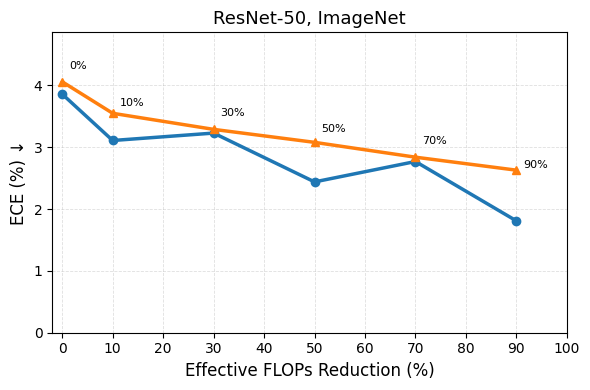

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Paths: ImageNet
# --------------------------------------------------

OUT_DIR = "PRUNING/RESNET50_IMAGENET/NLL_SBECE_PRUNE/ECE_FLOP_PLOTS"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PLOT = os.path.join(
    OUT_DIR,
    "ece_vs_effective_flops_ours_vs_gd_resnet50_imagenet.pdf"
)

OUT_MERGED_CSV = os.path.join(
    OUT_DIR,
    "ece_vs_effective_flops_ours_vs_gd_resnet50_imagenet.csv"
)


# --------------------------------------------------
# ImageNet data: ResNet-50
# --------------------------------------------------
# ECE values are from your ImageNet table.
# FLOP reduction values below are currently set equal to pruning levels.
# Replace them with actual effective FLOP reduction values if you have them.

imagenet_rows = [
    # pruning_%, ours_flop_reduction_%, gd_flop_reduction_%,
    # ours_ece_mean, ours_ece_std, gd_ece_mean, gd_ece_std

    [0,  0.00,  0.00,  3.86, 0.16, 4.06, 0.18],
    [10, 10.00, 10.00, 3.11, 0.15, 3.55, 0.16],
    [30, 30.00, 30.00, 3.23, 0.15, 3.29, 0.16],
    [50, 50.00, 50.00, 2.44, 0.14, 3.08, 0.16],
    [70, 70.00, 70.00, 2.77, 0.15, 2.84, 0.16],
    [90, 90.00, 90.00, 1.81, 0.15, 2.63, 0.16],
]

df_compare = pd.DataFrame(
    imagenet_rows,
    columns=[
        "pruning_%",
        "ours_flop_reduction_%",
        "gd_flop_reduction_%",
        "ours_ece_mean",
        "ours_ece_std",
        "gd_ece_mean",
        "gd_ece_std",
    ]
)

df_compare = df_compare.sort_values("pruning_%").reset_index(drop=True)

df_compare.to_csv(OUT_MERGED_CSV, index=False)
print("Saved merged CSV ->", OUT_MERGED_CSV)

display(df_compare)


# --------------------------------------------------
# Split into Ours and GD, same style as CIFAR code
# --------------------------------------------------

df_ours = df_compare[
    [
        "pruning_%",
        "ours_flop_reduction_%",
        "ours_ece_mean",
        "ours_ece_std",
    ]
].copy()

df_gd = df_compare[
    [
        "pruning_%",
        "gd_flop_reduction_%",
        "gd_ece_mean",
        "gd_ece_std",
    ]
].copy()


# --------------------------------------------------
# Plot ECE vs Effective FLOP Reduction
# Same visual style as CIFAR plots
# --------------------------------------------------

plt.figure(figsize=(6, 4))

# Ours
plt.plot(
    df_ours["ours_flop_reduction_%"],
    df_ours["ours_ece_mean"],
    marker="o",
    linewidth=2.5,
    markersize=6
    
)

# GD
plt.plot(
    df_gd["gd_flop_reduction_%"],
    df_gd["gd_ece_mean"],
    marker="^",
    linewidth=2.5,
    markersize=6
   
)


# --------------------------------------------------
# Cleaner pruning annotations: one label per pruning level
# --------------------------------------------------

LABEL_OFFSETS = {
    0:  (5, 8),
    10: (5, 4),
    30: (5, 8),
    50: (5, 6),
    70: (5, 8),
    90: (5, 0),
}

for _, row in df_compare.iterrows():
    p = int(row["pruning_%"])

    # Put label at the higher of Ours/GD to avoid overlap
    x_pos = 0.5 * (
        row["ours_flop_reduction_%"] + row["gd_flop_reduction_%"]
    )

    y_pos = max(
        row["ours_ece_mean"],
        row["gd_ece_mean"]
    )

    dx, dy = LABEL_OFFSETS.get(p, (5, 6))

    plt.annotate(
        f"{p}%",
        xy=(x_pos, y_pos),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.12",
            facecolor="white",
            edgecolor="none",
            alpha=0.80,
        ),
    )


# --------------------------------------------------
# Formatting
# --------------------------------------------------

plt.xlabel("Effective FLOPs Reduction (%)", fontsize=12)
plt.ylabel("ECE (%) ↓", fontsize=12)
plt.title("ResNet-50, ImageNet", fontsize=13)

plt.xlim(-2, 100)
plt.xticks(np.arange(0, 101, 10))

y_min = 0
y_max = max(
    df_ours["ours_ece_mean"].max(),
    df_gd["gd_ece_mean"].max()
) + 0.8

plt.ylim(y_min, y_max)

plt.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)

# Keep legend if this plot is used standalone.
# For stacked final figure, you may comment this out.
plt.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    OUT_PLOT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    transparent=False,
)

print("Saved plot ->", OUT_PLOT)

plt.show()